In [39]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


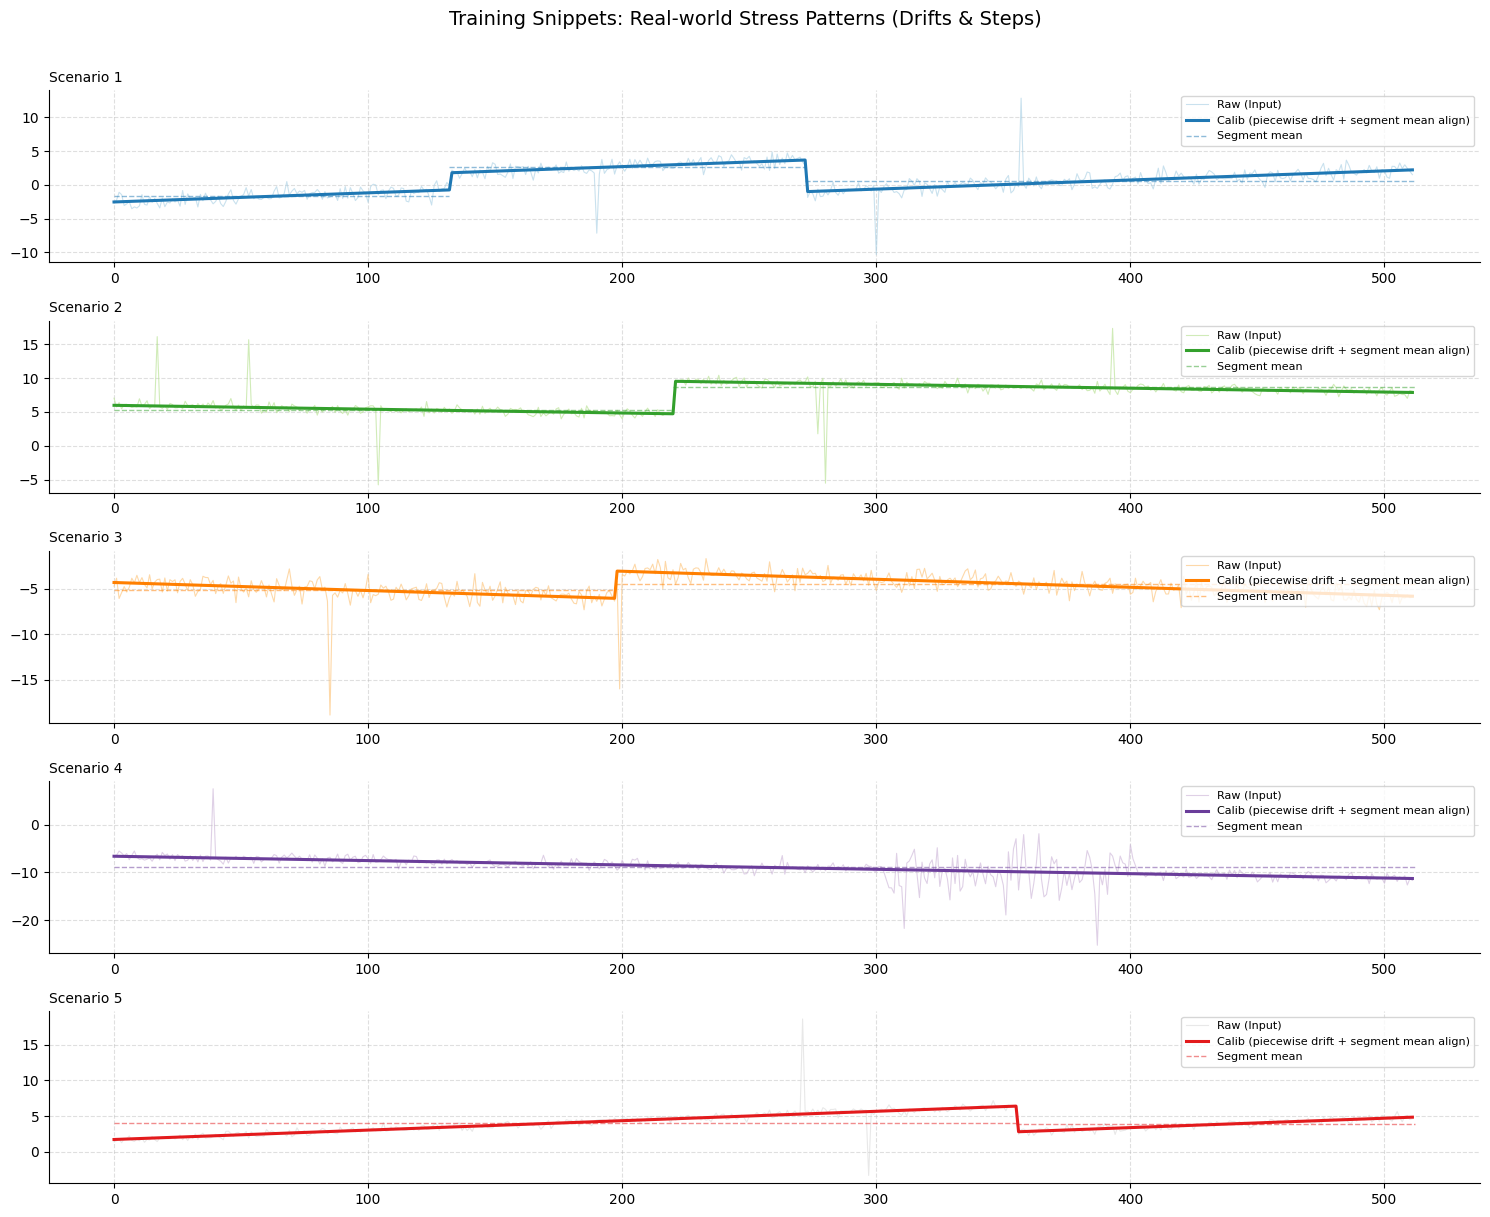

Done


In [43]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def generate_stress_snippets(n_snippets=1000, length=512):
    X, Y = [], []

    for i in range(n_snippets):
        time = np.arange(length)
        start_val = np.random.uniform(-10, 10)
        slope     = np.random.uniform(-0.015, 0.015)
        base      = start_val + slope * time   # nền drift tuyến tính

        case = np.random.choice(
            ['pure_drift', 'step_drift', 'multi_step_drift', 'burst_noise'],
            p=[0.25, 0.30, 0.25, 0.20]
        )

        # ── breakpoints để tính segment mean sau ──
        breakpoints = []

        if case == 'step_drift':
            split    = np.random.randint(150, length - 150)
            step_val = np.random.uniform(3, 7) * np.random.choice([-1, 1])
            base[split:] += step_val
            breakpoints   = [split]

        elif case == 'multi_step_drift':
            splits = np.sort(
                np.random.choice(np.arange(100, length - 100), 2, replace=False)
            )
            base[splits[0]:] += np.random.uniform(2, 4)
            base[splits[1]:] -= np.random.uniform(3, 5)
            breakpoints       = splits.tolist()

        # ── raw signal ──
        noise_std = np.random.uniform(0.2, 0.8)
        raw       = base + np.random.normal(0, noise_std, length)

        if case == 'burst_noise':
            b_start = np.random.randint(50, length - 150)
            raw[b_start:b_start + 100] += np.random.normal(0, noise_std * 5, 100)

        # spikes
        if np.random.rand() < 0.8:
            n_spikes = np.random.randint(2, 8)
            idx      = np.random.choice(length, n_spikes, replace=False)
            raw[idx] += (
                np.random.uniform(8, 15, n_spikes)
                * np.random.choice([-1, 1], n_spikes)
            )

        # ── xây label ──
        if breakpoints:
            # Có step → label = piecewise linear (drift) trong mỗi segment
            # ĐỒNG THỜI căn chỉnh offset để mean mỗi đoạn khớp với raw
            label  = np.empty(length)
            edges  = [0] + breakpoints + [length]
            for k in range(len(edges) - 1):
                s, e   = edges[k], edges[k + 1]
                seg_t  = np.arange(e - s)
                # fit đường thẳng trên raw (loại spike bằng clip)
                seg_raw = np.clip(
                    raw[s:e],
                    np.percentile(raw[s:e], 5),
                    np.percentile(raw[s:e], 95)
                )
                seg_mean   = seg_raw.mean()
                seg_slope  = slope   # giữ nguyên slope gốc của segment
                seg_center = (e - s) / 2
                # label = đường drift qua mean của đoạn
                label[s:e] = seg_mean + seg_slope * (seg_t - seg_center)
        else:
            # Không step → label = piecewise linear = chính là base drift
            label = base.copy()

        X.append(raw)
        Y.append(label)

    return np.array(X), np.array(Y)


# ── Vẽ minh họa ──
np.random.seed(42)
X_vis, Y_vis = generate_stress_snippets(n_snippets=5)

colors_raw   = ['#A6CEE3', '#B2DF8A', '#FDBF6F', '#CAB2D6', '#D9D9D9']
colors_calib = ['#1F78B4', '#33A02C', '#FF7F00', '#6A3D9A', '#E31A1C']

fig, axes = plt.subplots(5, 1, figsize=(15, 12))
fig.suptitle(
    "Training Snippets: Real-world Stress Patterns (Drifts & Steps)",
    fontsize=14, y=1.01
)

for i, ax in enumerate(axes):
    ax.plot(X_vis[i], color=colors_raw[i],   alpha=0.6, lw=0.8, label='Raw (Input)')
    ax.plot(Y_vis[i], color=colors_calib[i], lw=2.2,
            label='Calib (piecewise drift + segment mean align)')

    # vẽ đường segment mean ngang để so sánh
    y = Y_vis[i]
    # tìm breakpoint từ bước nhảy lớn của label
    diff   = np.abs(np.diff(y))
    thresh = diff.mean() + 3 * diff.std()
    bkps   = np.where(diff > thresh)[0]
    edges  = [0] + bkps.tolist() + [len(y)]
    for k in range(len(edges) - 1):
        s, e = edges[k], edges[k + 1]
        seg_mean = y[s:e].mean()
        ax.hlines(seg_mean, s, e,
                  colors=colors_calib[i], linestyles='--',
                  lw=1.0, alpha=0.5, label='Segment mean' if k == 0 else '')

    ax.set_title(f"Scenario {i+1}", fontsize=10, loc='left')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()
print("Done")

# Generate training data and reshape to (n_snippets, length, 1)
X_train, Y_train = generate_stress_snippets(n_snippets=1000)
X_train = X_train[..., np.newaxis]
Y_train = Y_train[..., np.newaxis]


In [44]:
from tensorflow.keras import layers, models
import tensorflow as tf

def calib_loss(y_true, y_pred):
    mae = tf.reduce_mean(tf.abs(y_true - y_pred))
    # Ép output phẳng — penalize biến động giữa 2 timestep liên tiếp
    tv  = tf.reduce_mean(tf.abs(y_pred[:, 1:, :] - y_pred[:, :-1, :]))
    # Ép giữ step change lớn khi cần
    step_diff_pred = tf.abs(y_pred[:, 1:, :] - y_pred[:, :-1, :])
    step_diff_true = tf.abs(y_true[:, 1:, :] - y_true[:, :-1, :])
    step_penalty   = tf.reduce_mean(tf.abs(step_diff_pred - step_diff_true))
    return mae + 0.5 * tv + 0.3 * step_penalty

def build_calib_unet(input_shape=(512, 1)):
    inputs = layers.Input(shape=input_shape)

    # Encoder: Kernel 15 giúp lọc nhiễu diện rộng
    c1 = layers.Conv1D(32, 15, activation='relu', padding='same')(inputs)
    p1 = layers.MaxPooling1D(2)(c1)

    c2 = layers.Conv1D(64, 15, activation='relu', padding='same')(p1)
    p2 = layers.MaxPooling1D(2)(c2)

    # Bottleneck
    b1 = layers.Conv1D(128, 15, activation='relu', padding='same')(p2)

    # Decoder
    u1 = layers.UpSampling1D(2)(b1)
    m1 = layers.Concatenate()([u1, c2])
    c3 = layers.Conv1D(64, 15, activation='relu', padding='same')(m1)

    u2 = layers.UpSampling1D(2)(c3)
    m2 = layers.Concatenate()([u2, c1])
    c4 = layers.Conv1D(32, 15, activation='relu', padding='same')(m2)

    # Output
    outputs = layers.Conv1D(1, 1, activation='linear')(c4)

    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss=calib_loss)
    return model

model = build_calib_unet()
model.fit(X_train, Y_train, epochs=50, batch_size=32, verbose=1)

Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 338ms/step - loss: 0.9412
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 343ms/step - loss: 0.2996
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 381ms/step - loss: 0.2561
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 19s 331ms/step - loss: 0.2146
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 338ms/step - loss: 0.1873
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 330ms/step - loss: 0.1903
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 319ms/step - loss: 0.1727
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 321ms/step - loss: 0.1481
Epoch 9/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 21s 328ms/step - loss: 0.1743
Epoch 10/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 341ms/step - loss: 0.1468
Epoch 11/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 342ms/step - loss: 0.1385
Epoch 12/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 316ms/step - loss: 0.1336
Epoch 13/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 21s 328ms/step - loss: 0.1280
Epoch 14/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 335ms/step - loss: 0.1190
Epoch 15/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 

In [73]:
import tensorflow as tf

# Save the model
model_path = '/content/calib_unet_model.keras'
model.save(model_path)
print(f"Model saved to {model_path}")

# Load the model later
# You need to pass the custom loss function when loading
loaded_model = tf.keras.models.load_model(model_path, custom_objects={'calib_loss': calib_loss})
print("Model loaded successfully!")

Model saved to /content/calib_unet_model.keras
Model loaded successfully!


In [66]:
import os

# 1. Load data
file_path = '/content/drive/MyDrive/Ung_suat_RM2/Ứng suất bản nắp hạ lưu đốt SK5_from_20230930T142035_to_20260318T142035.csv'
# Extract the filename with extension
full_name = os.path.basename(file_path)
# Extract just the name without the .csv extension
file_title = os.path.splitext(full_name)[0]

df = pd.read_csv(file_path, low_memory=False)
df.columns = df.columns.str.strip()
print('Loading data:', file_title)
print(df.head())

# 2. Setup Index
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df_filtered = df.sort_values('Timestamp').set_index('Timestamp')

dt = (df_filtered.index[1] - df_filtered.index[0]).total_seconds() / 3600
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# 1. Prepare data with Timestamps
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# 1. Automatically find the columns using keywords
# We search for columns containing 'Contrainte' and 'Temp' (case-insensitive)
contrainte_col = [c for c in df.columns if 'contrainte' in c.lower()][0]
temp_col = [c for c in df.columns if 'temp' in c.lower()][0]

print(f"Found columns: {contrainte_col} and {temp_col}")

# 2. Prepare data using the dynamic names
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Extract and clean
f_raw = pd.to_numeric(df[contrainte_col], errors='coerce').interpolate()

Loading data: Ứng suất bản nắp hạ lưu đốt SK5_from_20230930T142035_to_20260318T142035
             Timestamp Contrainte(16)  Temp(16)
0  2024-11-25 10:30:00            NaN     -96.2
1  2024-11-25 10:45:00            NaN     -96.2
2  2024-11-25 11:00:00            NaN     -96.2
3  2024-11-25 11:15:00            NaN     -96.2
4  2024-11-25 11:30:00            NaN     -96.2
Found columns: Contrainte(16) and Temp(16)


In [68]:
import numpy as np
from scipy.signal import savgol_filter
from scipy.stats import linregress

def auto_calib_patch_predict(long_raw_series, model,
                             patch_size=512,
                             stride=256,
                             batch_size=128):
    """
    Patch Predict cho dữ liệu cực dài (ví dụ 262,800 điểm)
    bằng cách sử dụng model có input_shape=(512, 1)
    """

    # 1. Chuyển đổi và xử lý lỗi dữ liệu đầu vào
    if hasattr(long_raw_series, 'values'):
        signal = long_raw_series.values.flatten().astype(np.float32)
    else:
        signal = np.array(long_raw_series).flatten().astype(np.float32)

    # Khử NaN ngay lập tức để tránh lỗi lan truyền
    if np.isnan(signal).any():
        mask = ~np.isnan(signal)
        indices = np.arange(len(signal))
        signal = np.interp(indices, indices[mask], signal[mask])

    n = len(signal)
    print(f"[INFO] Bắt đầu xử lý chuỗi dài: {n:,} điểm")

    # 2. Tách Global Trend (để model chỉ tập trung xử lý sai số cục bộ)
    x = np.arange(n)
    slope, intercept, r_value, p_value, std_err = linregress(x, signal)
    trend = slope * x + intercept
    detrended_signal = signal - trend

    # 3. Tạo các Patch (Windows)
    # Tính toán các điểm bắt đầu sao cho bao phủ hết n điểm
    starts = np.arange(0, n - patch_size + 1, stride)
    if starts[-1] + patch_size < n:
        starts = np.append(starts, n - patch_size)

    # Gom các miếng cắt (patches)
    patches = []
    for s in starts:
        patches.append(detrended_signal[s:s + patch_size])

    patches = np.array(patches).reshape(-1, patch_size, 1)
    print(f"[INFO] Tổng số patches: {len(patches)} | Batch size: {batch_size}")

    # 4. Batch Predict
    # Đây là nơi model "thông minh" làm việc
    preds = model.predict(patches, batch_size=batch_size, verbose=1)
    preds = preds.reshape(len(starts), patch_size)

    # 5. Tái cấu trúc chuỗi (Reconstruction) bằng phương pháp cộng dồn trung bình
    reconstructed = np.zeros(n)
    weights = np.zeros(n)

    for i, start in enumerate(starts):
        reconstructed[start:start + patch_size] += preds[i]
        weights[start:start + patch_size] += 1

    # Chia cho trọng số để làm mượt các đoạn chồng lấn (overlap)
    final_residual = reconstructed / weights

    # 6. Cộng lại Global Trend ban đầu
    calibrated_signal = final_residual + trend

    # 7. Làm mượt hậu kỳ (Savitzky-Golay)
    # Giúp loại bỏ các "khớp nối" nhỏ giữa các patch
    calibrated_signal = savgol_filter(calibrated_signal, window_length=101, polyorder=2)

    print("[INFO] Hoàn thành Calibrate.")
    return calibrated_signal.astype(np.float32)

# --- ÁP DỤNG ---
# Giả sử f_raw của bạn có 262,800 điểm
df['AI_Calibrated'] = auto_calib_patch_predict(f_raw, loaded_model)

[INFO] Bắt đầu xử lý chuỗi dài: 35,022 điểm
[INFO] Tổng số patches: 136 | Batch size: 128
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step 
[INFO] Hoàn thành Calibrate.


In [70]:
pip install ruptures

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 18.0 MB/s eta 0:00:00


In [71]:
import numpy as np
import ruptures as rpt  # Cần: pip install ruptures
from scipy.signal import savgol_filter

def auto_calib_with_pelt(long_raw_series, model, pelt_penalty=10):
    """
    Quy trình: Patch Predict -> PELT Changepoint -> Smoothing
    pelt_penalty: Độ nhạy (Càng cao thì càng ít đoạn bậc thang, càng mịn)
    """
    # 1. Lấy kết quả từ AI (Sử dụng hàm patch_predict đã viết ở trên)
    # Giả sử hàm này trả về chuỗi đã calibrate
    calib_ai = auto_calib_patch_predict(long_raw_series, model)

    print(f"[INFO] Đang chạy PELT để khử nhiễu bậc thang...")

    # 2. Áp dụng thuật toán PELT
    # Model "l2" thường dùng để tìm sự thay đổi về giá trị trung bình (mean)
    algo = rpt.Pelt(model="l2").fit(calib_ai)

    # Tìm các điểm ngắt. Penalty càng lớn, đường càng "phẳng"
    result = algo.predict(pen=pelt_penalty)

    # 3. Làm mịn theo từng đoạn (Piecewise Constant)
    # Chúng ta thay thế các giá trị trong mỗi đoạn bằng giá trị trung bình của đoạn đó
    pelt_signal = np.zeros_like(calib_ai)
    start_idx = 0
    for end_idx in result:
        # Lấy giá trị trung bình của đoạn để khử nhiễu hoàn toàn
        mean_val = np.mean(calib_ai[start_idx:end_idx])
        pelt_signal[start_idx:end_idx] = mean_val
        start_idx = end_idx

    # 4. Optional: Savitzky-Golay lần cuối để làm mượt các góc nhọn của bậc thang
    final_smooth = savgol_filter(pelt_signal, window_length=51, polyorder=1)

    return final_smooth

# --- CHẠY ---
# f_raw: 262,800 điểm
df['AI_PELT_Calibrated'] = auto_calib_with_pelt(df['AI_Calibrated'], model, pelt_penalty=15)

[INFO] Bắt đầu xử lý chuỗi dài: 35,022 điểm
[INFO] Tổng số patches: 136 | Batch size: 128
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step
[INFO] Hoàn thành Calibrate.
[INFO] Đang chạy PELT để khử nhiễu bậc thang...


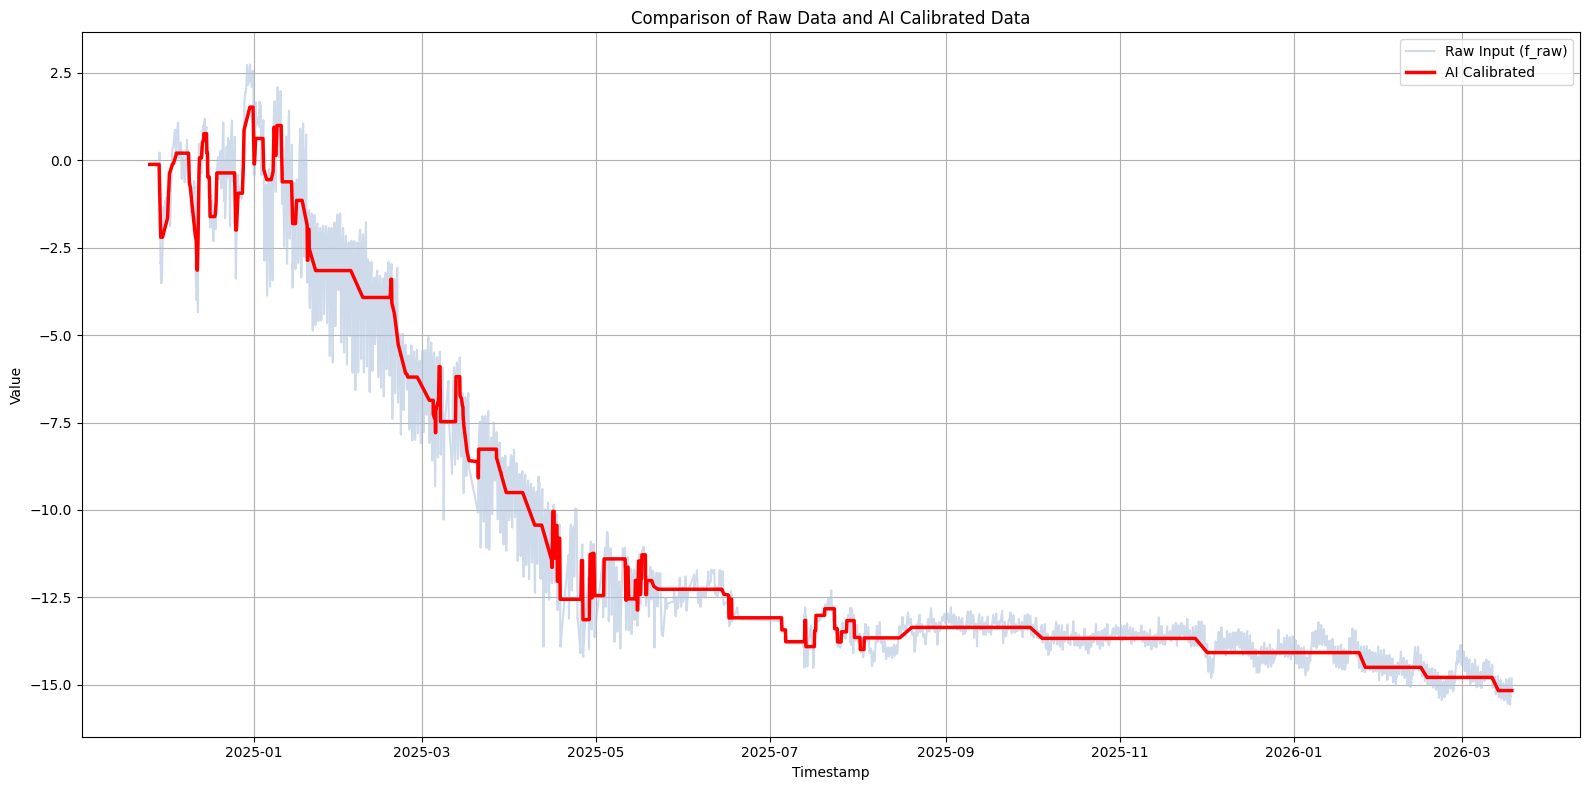

In [72]:
# ── Plot ──
plt.figure(figsize=(16, 8))
plt.plot(df['Timestamp'], f_raw,
         color='lightsteelblue', alpha=0.6, label='Raw Input (f_raw)')
plt.plot(df['Timestamp'], df['AI_PELT_Calibrated'],
         color='red', linewidth=2.5, label='AI Calibrated')
plt.title("Comparison of Raw Data and AI Calibrated Data")
plt.xlabel('Timestamp')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()